# Day 16 of ML 30-Days Challenge

# Task

**Logistic Regression**: Understand and implement your first classification model. Learn how the sigmoid function maps any real-valued number into a probability, and how to interpret the output as the likelihood of belonging to a particular class.

In [25]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
import seaborn as sns
import matplotlib.pyplot as plt

###1. Generate a 200-row binary classification dataset and prepare it

In [26]:
X, y = make_classification(
    n_samples=200,
    n_features=6,
    n_informative=3,
    n_redundant=1,
    n_repeated=0,
    n_clusters_per_class=2,
    class_sep=1.2,
    flip_y=0.03,
    random_state=42
)

feature_names = [f"feature_{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

X = df[feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, stratify=y, random_state=42 )

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

df.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,target
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000
mean,-0.071347,-0.449226,-0.004872,0.602979,-0.098337,-0.464149,0.49500
std,0.904476,1.364574,1.078150,1.461047,1.550307,1.346103,0.50123
min,-2.659351,-3.577452,-3.480809,-3.209166,-2.823202,-3.809086,0.00000
25%,-0.684614,-1.325966,-0.751260,-0.341592,-1.390503,-1.467649,0.00000
50%,-0.018446,-0.577308,-0.056699,0.795680,-0.578101,-0.616351,0.00000
75%,0.564383,0.359614,0.798040,1.771488,1.054331,0.238816,1.00000
max,2.182507,3.492373,2.965010,3.731827,4.798515,3.260254,1.00000


###2. Training the Logistic Regression Model

In [27]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

###3. Making Predictions and Understanding Probabilities

In [28]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

###4. Initial Model Evaluation

In [29]:
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=3)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", round(acc, 4))
print("ROC AUC:", round(roc_auc, 4))
print("\nClassification Report:\n", report)

Accuracy: 0.98
ROC AUC: 0.968

Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.960     0.980        25
           1      0.962     1.000     0.980        25

    accuracy                          0.980        50
   macro avg      0.981     0.980     0.980        50
weighted avg      0.981     0.980     0.980        50



###5. Visualizations

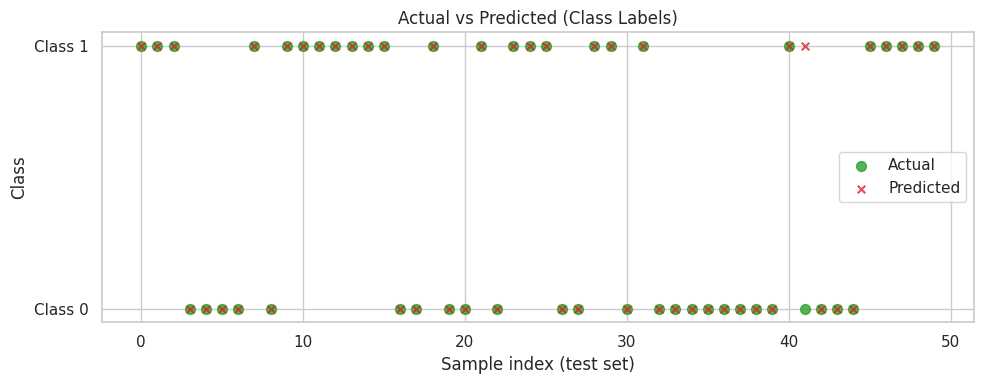

In [30]:
viz_df = pd.DataFrame({
    "index": np.arange(len(y_test)),
    "actual": y_test,
    "pred": y_pred,
    "proba": y_proba
})

plt.figure(figsize=(10, 4))
plt.scatter(viz_df["index"], viz_df["actual"], s=50, alpha=0.8, label="Actual", c="tab:green")
plt.scatter(viz_df["index"], viz_df["pred"],   s=30, alpha=0.8, label="Predicted", c="tab:red", marker="x")
plt.yticks([0, 1], ["Class 0", "Class 1"])
plt.xlabel("Sample index (test set)")
plt.ylabel("Class")
plt.title("Actual vs Predicted (Class Labels)")
plt.legend()
plt.tight_layout()
plt.show()